<div class='alert alert-block alert-info"'>
<h1> An sdg4varselect example :</h1>

<h4> Variable selection and estimation in a joint model of logitic longitudinal data and survival data </h4>
</div>

In [5]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Dataset generation

First, let's generate a data set corresponding to a joint model of longitduinal logistic data and a Cox model.


$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_j; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_j}{\varphi_{3,i}} \right)}$ and $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

In [6]:
from sdg4varselect.models.logistic_joint_model import Logistic_JM
from sdg4varselect import DataHandler

model = Logistic_JM(N=100, J=5, DIM_HD=5)

# Simulation parameter
params_star = model.new_params(
    mu1=0.3,
    mu2=90.0,
    mu3=7.5,
    gamma2_1=0.0025,
    gamma2_2=20,
    sigma2=0.001,
    alpha=11.11,
    beta=jnp.concatenate(
        [jnp.array([-2, -3, 3, 2]), jnp.zeros(shape=(model.DIM_HD - 4,))]
    ),
)

obs, sim = model.sample(params_star, jrd.PRNGKey(0), weibull_censoring_loc=77)

dh = DataHandler(**obs)

_ = sdgplt.plot_sample(obs, sim, params_star, 77, 80, 35)

ImportError: cannot import name 'DataHandler' from 'sdg4varselect' (/home/acaillebotte/projects/sdg4varselect/sdg4varselect/__init__.py)

# Estimation example

try an estimation on the data set with the SPG-FIM algorithm

first we need to intiate the algorithm with accurate step size.

In [7]:
from sdg4varselect import SPG_FIM

# algorithm settings
algo_settings = SPG_FIM.SPGfimSettings(
    step_size_grad={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": 600,
        "max": 0.9,
    },
    step_size_approx_sto={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 1,
    },
    step_size_fisher={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 0.9,
    },
    max_iter=2000,
)

# for only estimation we set lambda = None
algo = SPG_FIM(jrd.PRNGKey(0), dh, algo_settings, lbd=None)
# We define the init value of the alogirthm drawn from a normal distribution
theta0 = 0.2 * jrd.normal(jrd.PRNGKey(0), shape=(model.parametrization.size,))

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


NameError: name 'dh' is not defined

we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [4]:
params0 = model.parametrization.reals1d_to_params(theta0)
algo.add_mcmc(
    0.2,
    sd=0.001,
    size=model.N,
    likelihood=model.likelihood_array,
    name="phi1",
)
algo.latent_variables["phi1"].adaptative_sd = True
algo.add_mcmc(
    45,
    sd=2,
    size=model.N,
    likelihood=model.likelihood_array,
    name="phi2",
)
algo.latent_variables["phi2"].adaptative_sd = True

In [5]:
from sdg4varselect.exceptions import sdg4vsNanError
from sdg4varselect.outputs import estim_res

try:
    res_estim = algo.fit(
        model.jac_likelihood,
        DIM_HD=model.DIM_HD,
        theta0_reals1d=theta0,
        ntry=5,
        partial_fit=False,
    )
except sdg4vsNanError as err:
    print(err)

res = algo.labelswitch(res_estim)

theta = jnp.array([model.reals1d_to_hstack_params(t) for t in res.theta])
res = estim_res(
    theta=theta,
    FIM=res.FIM,
    grad=res.grad,
    likelihood=algo.likelihood_marginal(model, jrd.PRNGKey(0), res.theta[-1]),
)

(<Figure size 1500x1500 with 5 Axes>,
 <AxesSubplot: title={'center': 'Parameter'}>)

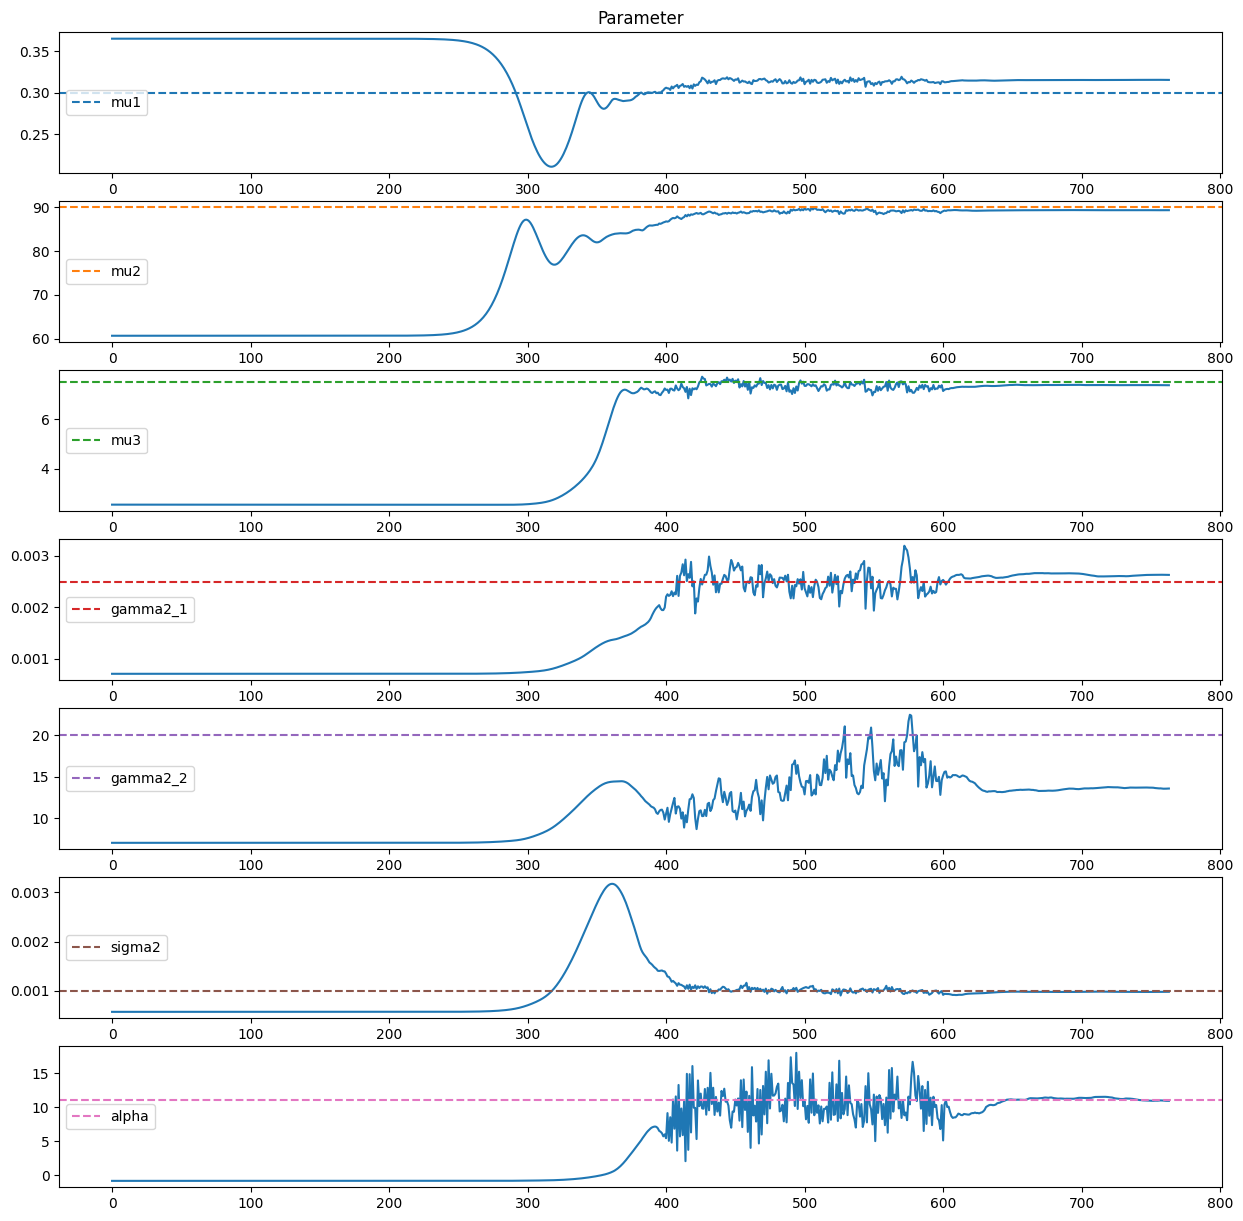

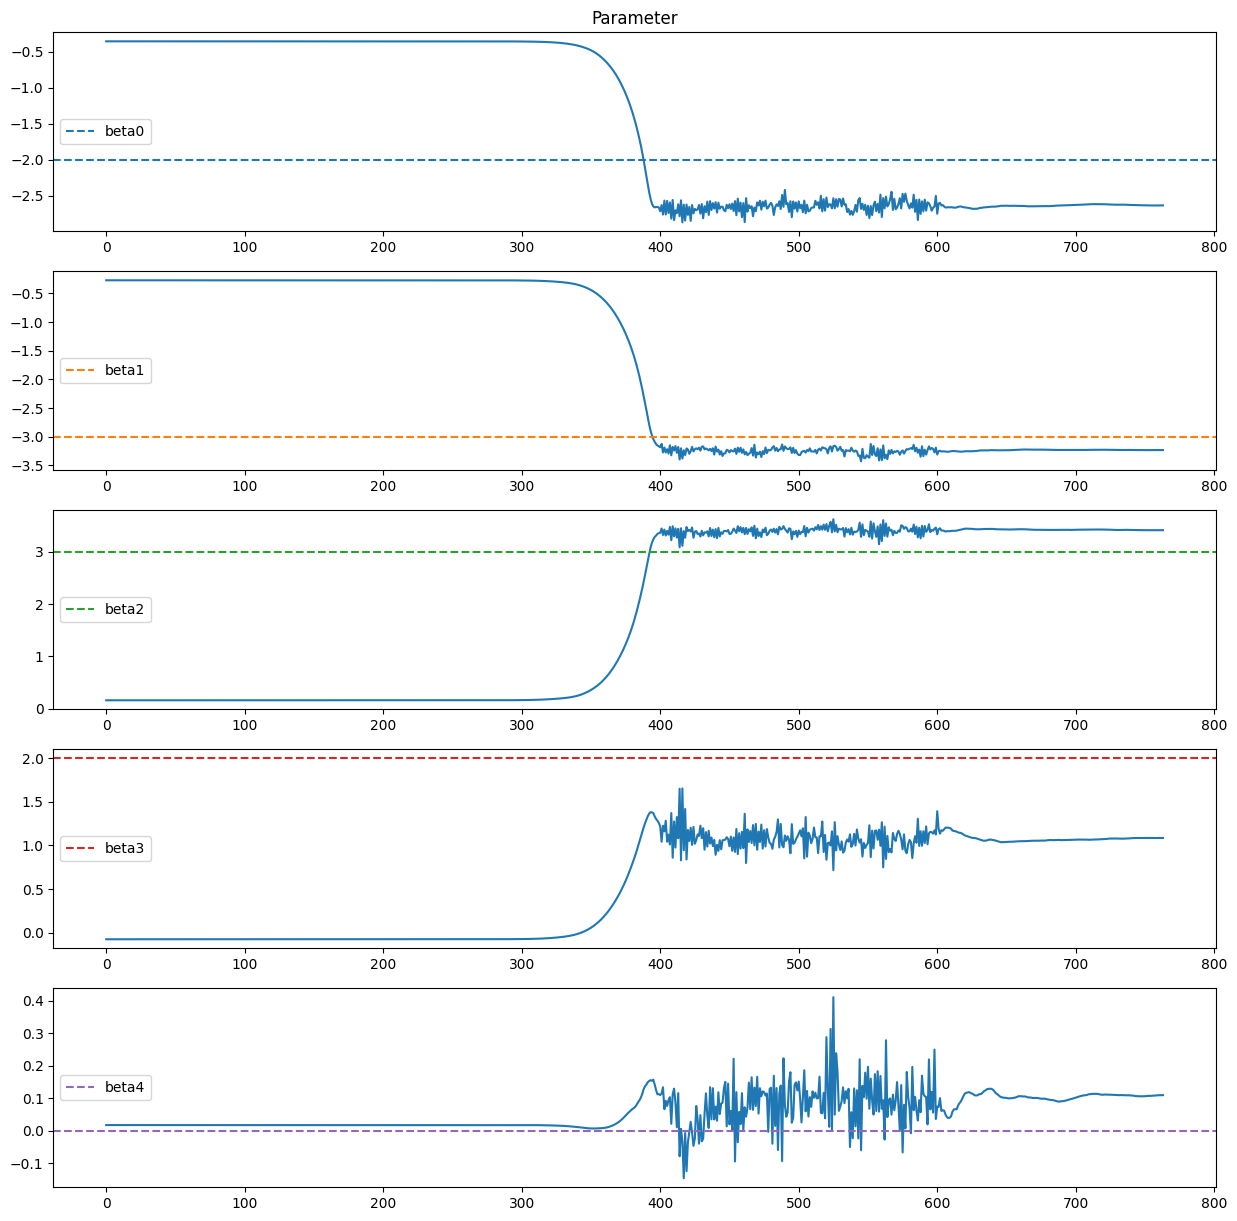

In [6]:
# === PLOT === #
from sdg4varselect.models.logistic_joint_model import get_params_star

params_star = get_params_star(model.DIM_HD)

sdgplt.plot_theta(res, model.DIM_LD, params_star, model.params_names)
sdgplt.plot_theta_HD(res, model.DIM_LD, params_star, model.params_names)